### Import Libraries

In [729]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


### Clean Up Data

<small>Read the data and convert into dataframe</small>
<small></small>

In [730]:
pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [731]:
from os import read
# read data from csv

import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

df = pd.read_csv(path + '/dirty_cafe_sales.csv')
print("Data loaded successfully.")

Data loaded successfully.


<small>Check the data set type using info</small>

In [732]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


<small>There are some null values in the dataset that need to be handled.</small>

<small>Check how the actual values look (overview)</small>

In [733]:
df.head(40)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


<small>Check unique values to sort out Erroneous data types</small>

<small>Based on the data, Erroneous data types are: ERROR, NaN, UNKNOWN</small>

In [734]:
# check column unique values 
print(df.nunique())

# get for the Item, Price Per Unit, Payment Method, Location
unique_items = df['Item'].unique().tolist()
unique_prices = df['Price Per Unit'].unique().tolist()
unique_payment_methods = df['Payment Method'].unique().tolist()
unique_locations = df['Location'].unique().tolist()


print("Unique Items:", unique_items)
print("Unique Prices:", unique_prices)
print("Unique Payment Methods:", unique_payment_methods)   
print("Unique Locations:", unique_locations)

# take note of erroneous data types
error_values = ["ERROR", "UNKNOWN", "NAN"]

Transaction ID      10000
Item                   10
Quantity                7
Price Per Unit          8
Total Spent            19
Payment Method          5
Location                4
Transaction Date      367
dtype: int64
Unique Items: ['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN', 'Sandwich', nan, 'ERROR', 'Juice', 'Tea']
Unique Prices: ['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN']
Unique Payment Methods: ['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan]
Unique Locations: ['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR']


<small>Check for null values per column</small>

In [735]:
print("Null Values in Each Column:")
print(df.isnull().sum())

Null Values in Each Column:
Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


<small>Check the data types</small>

In [736]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


<small>Convert to appropriate data type, apply coerce on errors to change to NaN or NaT</small>

In [737]:
# convert to correct data types

# numerical columns
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')
df['Total Price'] = df['Quantity'] * df['Price Per Unit']

# categorical columns
df['Item'] = df['Item'].astype('string')
df['Payment Method'] = df['Payment Method'].astype('string')
df['Location'] = df['Location'].astype('string')

# datetime column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')


<small>Recheck newly casted data types</small>

In [738]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    10000 non-null  object        
 1   Item              9667 non-null   string        
 2   Quantity          9521 non-null   float64       
 3   Price Per Unit    9467 non-null   float64       
 4   Total Spent       9498 non-null   float64       
 5   Payment Method    7421 non-null   string        
 6   Location          6735 non-null   string        
 7   Transaction Date  9540 non-null   datetime64[ns]
 8   Total Price       9006 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(1), string(3)
memory usage: 703.3+ KB


<small>Create a copy of the data frame. Make a helper function that converts values from the error_values list taken to a panda (pd.NA) or null value type in pandas. apply it on the copied dataframe, with axis set to "1" to apply to the rows</small>

In [739]:

df_clean = df.copy()

def clean_data(row): 
    for col in df_clean.columns:
        if isinstance(row[col], str):
            if row[col].upper() in error_values:
                row[col] = pd.NA
    return row

df_clean = df_clean.apply(clean_data, axis=1)


<small>Check actual null values are reflected in rows</small>

In [740]:
df_clean.head(40)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Total Price
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,12.0
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19,4.0
3,TXN_7034554,Salad,2.0,5.0,10.0,<NA>,<NA>,2023-04-27,10.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,<NA>,2023-03-31,20.0
6,TXN_4433211,<NA>,3.0,3.0,9.0,<NA>,Takeaway,2023-10-06,9.0
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,<NA>,2023-10-28,16.0
8,TXN_4717867,<NA>,5.0,3.0,15.0,<NA>,Takeaway,2023-07-28,15.0
9,TXN_2064365,Sandwich,5.0,4.0,20.0,<NA>,In-store,2023-12-31,20.0


<small>Recheck the number of nulls in the columns to see that they increased</small>

In [741]:
df_clean.isna().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
Total Price          994
dtype: int64

<small>Use different approaches to fill pd.NA types with appropriate values. By default, use Medians for numerical values, Mode for categorical. Total Price is a column calculated using other columns instead</small>

In [742]:
# First create a menu view table
menu_data = df_clean.groupby('Item')['Price Per Unit'].first().sort_values(ascending=False)
print(menu_data)

Item
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Cake        3.0
Juice       3.0
Coffee      2.0
Tea         1.5
Cookie      1.0
Name: Price Per Unit, dtype: float64


In [743]:
# fill data based on type, median or mode

# based on the data, and information on the data set
# We can use that information to infer missing values.
# In this case, we can make a dict of a corresponding item per price per unit
item_price_dict = menu_data.to_dict()

print("Menu Data:")
print(item_price_dict)

"""
Numerical Columns
"""
# Item
# Based on the data, get the item where the price per unit is the most frequent
# if any nulls remain, fill in with the mode
df_clean['Item']= df_clean['Item'].fillna(df_clean['Price Per Unit'].map({v: k for k, v in item_price_dict.items()}))
df_clean['Item']= df_clean['Item'].fillna(df_clean['Item'].mode()[0])

# Price Per Unit
# Based on the data, fill in with the calculated total spent divided by quantity
# if any nulls remain, fill in with the item price
df_clean['Price Per Unit']= df_clean['Price Per Unit'].fillna((df_clean['Total Spent'] / df_clean['Quantity']))
df_clean['Price Per Unit']= df_clean['Price Per Unit'].fillna(df_clean['Item'].map(item_price_dict))

# Quantity
# Based on the data, fill in with the calculated total spent divided by price per unit
df_clean['Quantity']= df_clean['Quantity'].fillna((df_clean['Total Spent'] / df_clean['Price Per Unit']))

# Total Spent
# Based on the data, fill in with the calculated quantity multiplied by price per unit
df_clean['Total Spent']= df_clean['Total Spent'].fillna(df_clean['Quantity'] * df_clean['Price Per Unit'])

# if any null remains in numerical columns, fill with median or mean as appropriate
# in this case, we use median to avoid skew from outliers
df_clean['Price Per Unit']= df_clean['Price Per Unit'].fillna(df_clean['Price Per Unit'].median())
df_clean['Quantity']= df_clean['Quantity'].fillna(df_clean['Quantity'].median())
df_clean['Total Spent']= df_clean['Total Spent'].fillna(df_clean['Total Spent'].median())

# Case Quantity to integer
df_clean['Quantity'] = df_clean['Quantity'].map(lambda x: int(x))


"""
Categorical Columns
"""
# Payment Method
# Fill with mode
df_clean['Payment Method']= df_clean['Payment Method'].fillna(df_clean['Payment Method'].mode()[0],)

# Location
# Fill with mode
df_clean['Location']= df_clean['Location'].fillna(df_clean['Location'].mode()[0])

# Transaction Date
# In order to differentiate missing dates, fill with a default date, in this case 1990-01-01
default_time = pd.Timestamp("1990-01-01 00:00:00")
df_clean['Transaction Date']= df_clean['Transaction Date'].fillna(default_time)

# Total Price
# At this point, quantity and price per unit should be filled, so recalculate
df_clean['Total Price'] = df_clean['Quantity'] * df_clean['Price Per Unit']

print("Succesfully turned null values in non-null.")


Menu Data:
{'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Cake': 3.0, 'Juice': 3.0, 'Coffee': 2.0, 'Tea': 1.5, 'Cookie': 1.0}
Succesfully turned null values in non-null.


<small>Recheck and confirm that there are no null values present in each column and that the Juice items have the correct price per unit.</small>

In [744]:
df_clean.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Total Price         0
dtype: int64

<small> **Extra Step:** Based on data observations, some rows contain inconsistent item-price mappings. Specifically, items labeled as "Juice" may have incorrect price values. To correct this, we'll use the `item_price_dict` to reverse-map prices back to their correct item names, ensuring consistency between items and their prices.</small>

In [745]:
# check unique item-price pairs to ensure consistency
df_clean[['Item', 'Price Per Unit']].drop_duplicates()


,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
5,Smoothie,4.0
6,Juice,3.0
7,Sandwich,4.0
14,Tea,1.5
151,Juice,4.0
289,Juice,1.5


<small>Handle the Juice items with incorrect Price Per Unit by using the menu data to correct them based on the price</small>

In [746]:
# Find all rows where Item is Juice but Price Per Unit is not the correct juice price
# and update the Item based on the Price Per Unit using the reverse mapping of item_price_dict

# Fix Juice items that has incorrect price per unit

juice_price = item_price_dict.get('Juice', None)

price_to_item_map = {v: k for k, v in item_price_dict.items()}
print("Price to Item Map:")
print(price_to_item_map)

df_clean.loc[
    (df_clean['Item'] == 'Juice') &
    (df_clean['Price Per Unit'].notna()) &
    (df_clean['Price Per Unit'] != juice_price),
    'Item'
] = df_clean.loc[
    (df_clean['Item'] == 'Juice') &
    (df_clean['Price Per Unit'].notna()) &
    (df_clean['Price Per Unit'] != juice_price),
    'Price Per Unit'
].map(price_to_item_map)

print("Data cleaning completed successfully for Juice items.")


Price to Item Map:
{5.0: 'Salad', 4.0: 'Smoothie', 3.0: 'Juice', 2.0: 'Coffee', 1.5: 'Tea', 1.0: 'Cookie'}
Data cleaning completed successfully for Juice items.


<small>Now we can recheck and confirm that there are no null values present in each column and that the Juice items have the correct price per unit.</small>

In [747]:
df_clean[['Item', 'Price Per Unit']].drop_duplicates()

,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
5,Smoothie,4.0
6,Juice,3.0
7,Sandwich,4.0
14,Tea,1.5


<small>Ensure Assumptions</small>

In [748]:
# Check Unique Values After Cleaning
clean_unique_items = df_clean['Item'].unique().tolist()
clean_unique_prices = df_clean['Price Per Unit'].unique().tolist()
clean_unique_payment_methods = df_clean['Payment Method'].unique().tolist()
clean_unique_locations = df_clean['Location'].unique().tolist()
print("Clean Unique Items:", clean_unique_items)
print("Clean Unique Prices:", clean_unique_prices)
print("Clean Unique Payment Methods:", clean_unique_payment_methods)
print("Clean Unique Locations:", clean_unique_locations)

Clean Unique Items: ['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Juice', 'Sandwich', 'Tea']
Clean Unique Prices: [2.0, 3.0, 1.0, 5.0, 4.0, 1.5]
Clean Unique Payment Methods: ['Credit Card', 'Cash', 'Digital Wallet']
Clean Unique Locations: ['Takeaway', 'In-store']


<small>Visualize the cleaned data</small>

In [749]:
df_clean.head(40)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Total Price
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,12.0
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,4.0
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,10.0
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,Takeaway,2023-03-31,20.0
6,TXN_4433211,Juice,3,3.0,9.0,Digital Wallet,Takeaway,2023-10-06,9.0
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,Takeaway,2023-10-28,16.0
8,TXN_4717867,Juice,5,3.0,15.0,Digital Wallet,Takeaway,2023-07-28,15.0
9,TXN_2064365,Sandwich,5,4.0,20.0,Digital Wallet,In-store,2023-12-31,20.0


### Feature Engineering

<small>Add a feature to categorize an item to either a 'food' or 'drink' depending on the unique item value found in the item column </small>

In [750]:
clean_unique_items = df_clean['Item'].unique().tolist()
print("Clean Unique Items:", clean_unique_items)

Clean Unique Items: ['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Juice', 'Sandwich', 'Tea']


<small>Based on the data of the unique values, categorize them into food and drink</small>

In [751]:
drinks = ['coffee', 'smoothie', 'juice', 'tea']
food = ['cake', 'cookie', 'salad', 'sandwich']

<small>Make a new column that lists the item as either a food or drink depending on the defined lists above</small>

In [752]:
df_clean["Item Type"] = df_clean["Item"].apply(
    lambda x: "Drink" if pd.notna(x) and x.lower() in drinks else "Food"
)

<small>Check if the new column is added</small>

In [753]:
df_clean.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Total Price,Item Type
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08,4.0,Drink
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16,12.0,Food
2,TXN_4271903,Cookie,4,1.0,4.0,Credit Card,In-store,2023-07-19,4.0,Food
3,TXN_7034554,Salad,2,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,10.0,Food
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11,4.0,Drink


<small>Add more columns to prepare for analysis</small>

In [754]:
# transaction day
df_clean['Transaction Day'] = df_clean['Transaction Date'].dt.day_name()

# transaction month 
df_clean['Transaction Month'] = df_clean['Transaction Date'].dt.month_name()

# transaction year
df_clean['Transaction Year'] = df_clean['Transaction Date'].dt.year

print('Successfully extracted added datetime features.')


Successfully extracted added datetime features.


### Analysis

<small>Total Sold Per Item, and total earnings</small>

In [755]:
total_sold_per_item = df_clean.groupby('Item')[['Quantity', 'Total Price']].sum().reset_index().sort_values(by='Quantity', ascending=False)

# Convert Quantity to integer
total_sold_per_item['Quantity'] = total_sold_per_item['Quantity'].map(lambda x: int(x))

total_sold_per_item

,Item,Quantity,Total Price
3,Juice,4298,12894.0
6,Smoothie,4046,16184.0
1,Coffee,3919,7838.0
4,Salad,3825,19125.0
7,Tea,3653,5479.5
2,Cookie,3604,3604.0
0,Cake,3471,10413.0
5,Sandwich,3441,13764.0


<small>Most to least sold item per day</small>

In [756]:
popular_items_per_day = df_clean.groupby(['Transaction Day', 'Item'])[['Quantity', 'Total Price']].sum().reset_index()
popular_items_per_day = popular_items_per_day.sort_values(['Transaction Day', 'Quantity'], ascending=[True, False])

# Convert Quantity to integer
popular_items_per_day['Quantity'] = popular_items_per_day['Quantity'].map(lambda x: int(x))
popular_items_per_day

,Transaction Day,Item,Quantity,Total Price
3,Friday,Juice,622,1866.0
6,Friday,Smoothie,608,2432.0
1,Friday,Coffee,602,1204.0
0,Friday,Cake,519,1557.0
2,Friday,Cookie,499,499.0
4,Friday,Salad,495,2475.0
7,Friday,Tea,456,684.0
5,Friday,Sandwich,414,1656.0
11,Monday,Juice,850,2550.0
15,Monday,Tea,739,1108.5


<small>Most to least sold item per month </small>

In [757]:
popular_items_per_month = df_clean.groupby(['Transaction Month', 'Item'])[['Quantity', 'Total Price']].sum().reset_index()
popular_items_per_month = popular_items_per_month.sort_values(['Transaction Month', 'Quantity'], ascending=[True, False])

# Convert Quantity to integer
popular_items_per_month['Quantity'] = popular_items_per_month['Quantity'].map(lambda x: int(x))
popular_items_per_month

,Transaction Month,Item,Quantity,Total Price
3,April,Juice,387,1161.0
6,April,Smoothie,339,1356.0
4,April,Salad,322,1610.0
1,April,Coffee,296,592.0
0,April,Cake,272,816.0
...,...,...,...,...
95,September,Tea,300,450.0
88,September,Cake,289,867.0
93,September,Sandwich,285,1140.0
89,September,Coffee,267,534.0


<small>Most to least sold item per year</small>

In [758]:
popular_items_per_year = df_clean.groupby(['Transaction Year', 'Item'])[['Quantity', 'Total Price']].sum().reset_index()
popular_items_per_year = popular_items_per_year.sort_values(['Transaction Year', 'Quantity'], ascending=[True, False])

# Convert Quantity to integer
popular_items_per_year['Quantity'] = popular_items_per_year['Quantity'].map(lambda x: int(x))
popular_items_per_year

,Transaction Year,Item,Quantity,Total Price
7,1990,Tea,209,313.5
3,1990,Juice,204,612.0
0,1990,Cake,190,570.0
6,1990,Smoothie,177,708.0
4,1990,Salad,175,875.0
2,1990,Cookie,171,171.0
5,1990,Sandwich,162,648.0
1,1990,Coffee,138,276.0
11,2023,Juice,4094,12282.0
14,2023,Smoothie,3869,15476.0


<small>Most Popular Location Types</small>

In [759]:
most_popular_location = df_clean.groupby('Location')[['Quantity', 'Total Price']].sum().reset_index().sort_values(by='Quantity', ascending=False)
print(most_popular_location)

print(df_clean["Location"].mode()[0])

   Location  Quantity  Total Price
1  Takeaway     21089      62046.0
0  In-store      9168      27255.5
Takeaway


<small>Most Popular Payment Methods</small>

In [760]:
most_popular_payment_method = df_clean.groupby('Payment Method')[['Quantity', 'Total Price']].sum().reset_index().sort_values(by='Quantity', ascending=False)
print(most_popular_payment_method)

print(df_clean["Payment Method"].mode()[0])

   Payment Method  Quantity  Total Price
2  Digital Wallet     16539      48360.0
1     Credit Card      6865      20500.0
0            Cash      6853      20441.5
Digital Wallet


### Analysis on Skewness, Correlation and Outliers

<small>Skewness with histograms (Total Price & Quantity)</small>

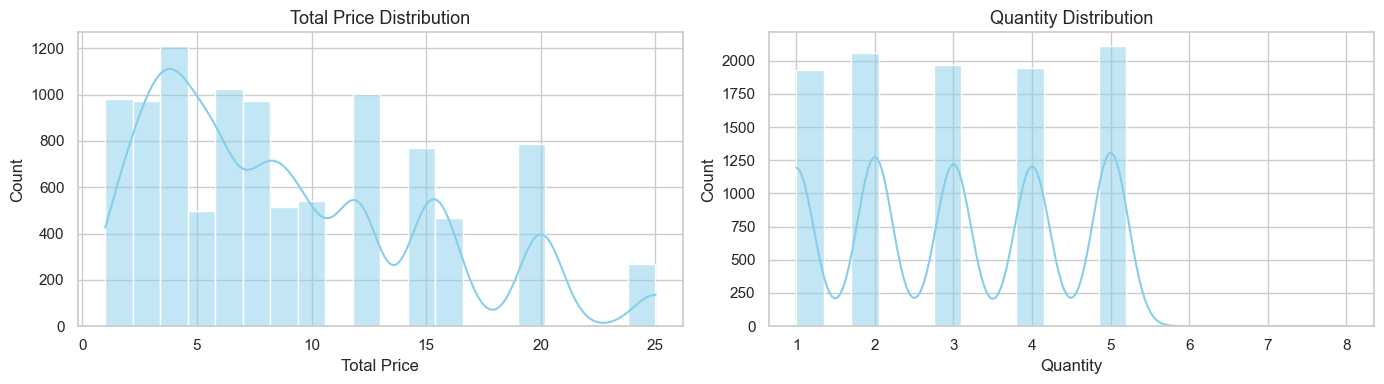

Skewness of Total Price: 0.82
Skewness of Quantity: -0.00


In [761]:
# analyze skewneess of total price and quantity (they have some correlation)
skew_cols = ['Total Price', 'Quantity']

fig, axes = plt.subplots(1, len(skew_cols), figsize=(7 * len(skew_cols), 4))
axes = np.atleast_1d(axes)  

for ax, col in zip(axes, skew_cols):
    sns.histplot(df_clean[col], kde=True, color='skyblue', ax=ax, bins=20)
    ax.set_title(f'{col} Distribution', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

for col in skew_cols:
    print(f"Skewness of {col}: {df_clean[col].skew():.2f}")

<small>Correlation heatmap</small>

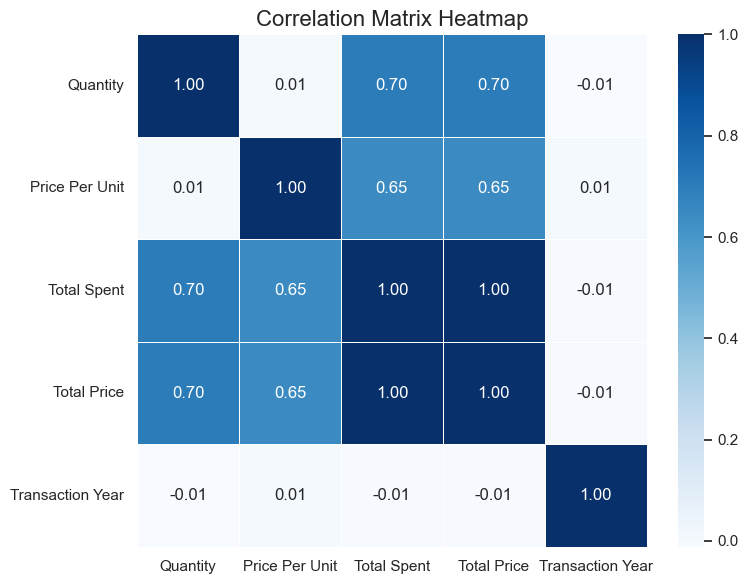

In [762]:

# compute correlation on non categorical columns to find if there are any interesting relationships
corr_matrix = df_clean.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

<small>Outliers detection (boxplots) and removal via IQR</small>

--CONTAINING OUTLIERS--


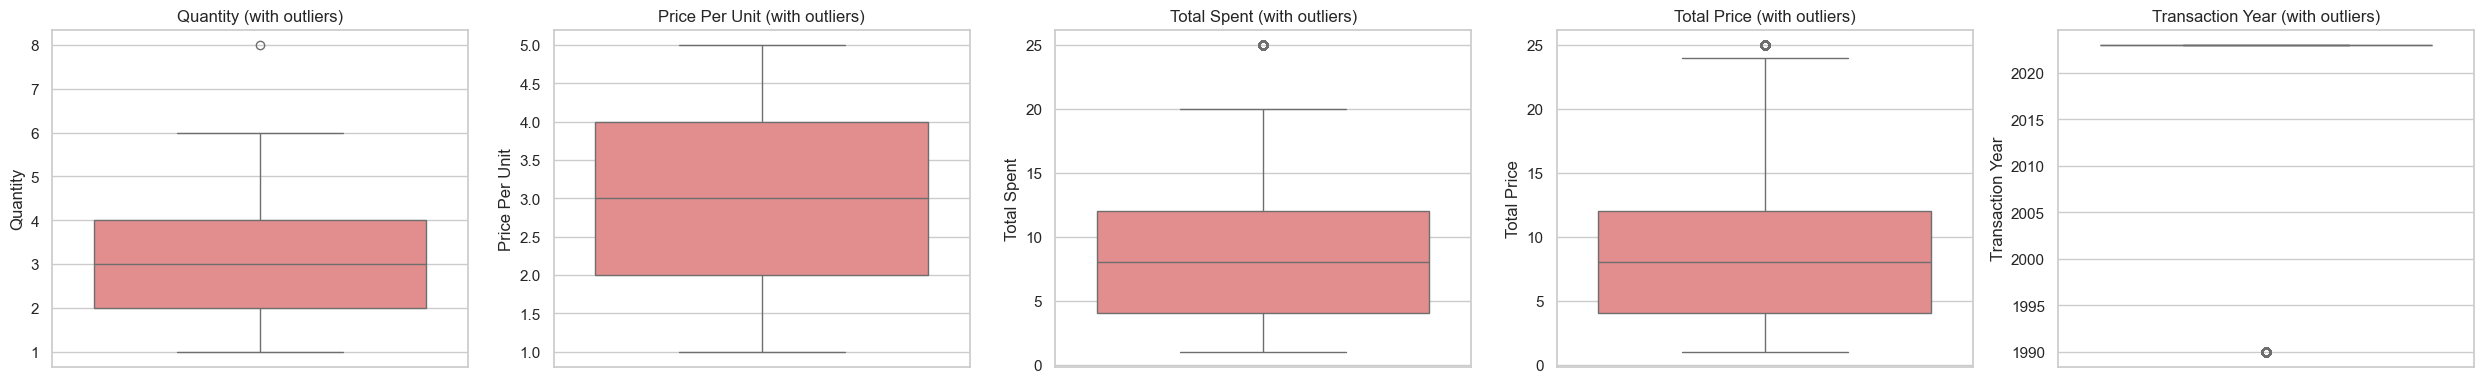

--REMOVED OUTLIERS--


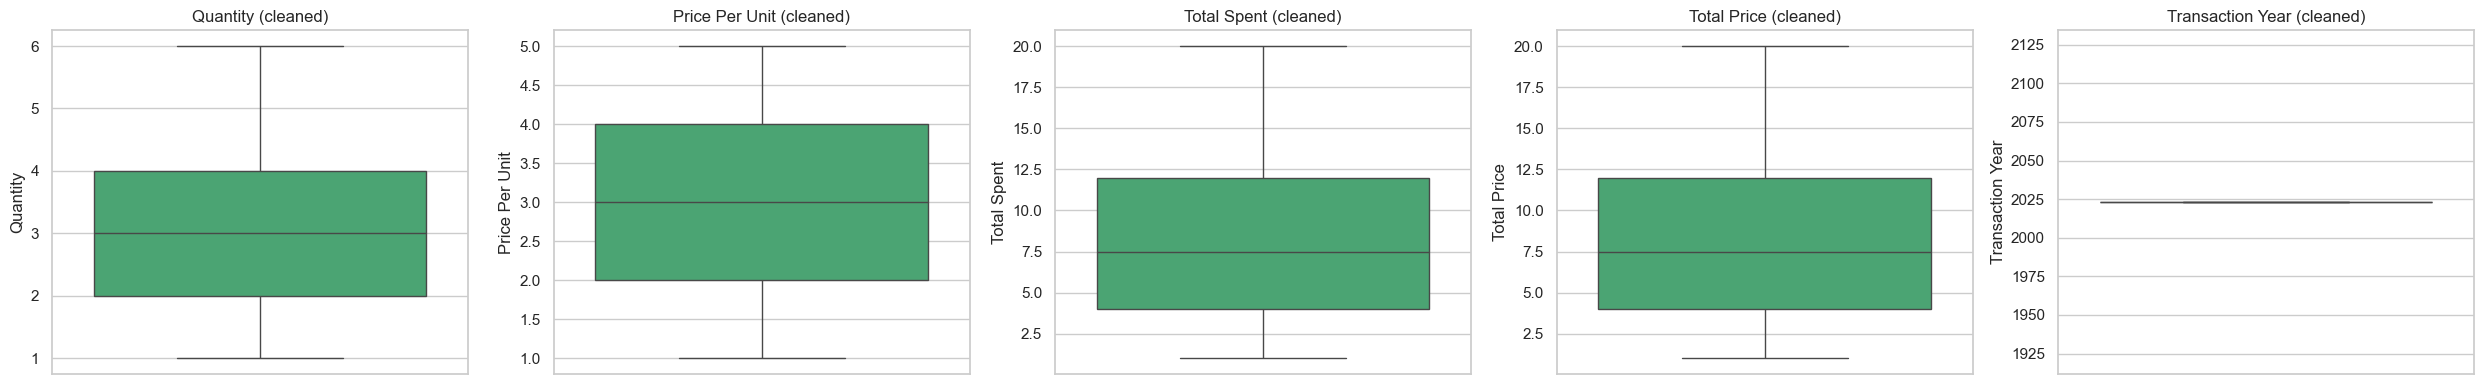

In [763]:

# IQR method to remove outliers 

def remove_outliers_iqr(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return data[(data[column] >= lower) & (data[column] <= upper)]

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print("--CONTAINING OUTLIERS--")
# boxplots before removal
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='lightcoral')
    ax.set_title(f'{col} (with outliers)', fontsize=12)
plt.tight_layout()
plt.show()



df_no_outliers = df_clean.copy()
for col in numeric_cols:
    before = len(df_no_outliers)
    df_no_outliers = remove_outliers_iqr(df_no_outliers, col)
    removed = before - len(df_no_outliers)
   

print("--REMOVED OUTLIERS--")

# boxplots after removal
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 4))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_no_outliers[col], ax=ax, color='mediumseagreen')
    ax.set_title(f'{col} (cleaned)', fontsize=12)
plt.tight_layout()
plt.show()

### PreProcessing

In [764]:
import sklearn

<small>list columns to analyze features </small>

In [765]:
df_clean.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date', 'Total Price',
       'Item Type', 'Transaction Day', 'Transaction Month',
       'Transaction Year'],
      dtype='object')

In [766]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
#features
X = df_clean[['Item', 'Price Per Unit']]

#targets

y = df_clean['Item Type']

print("--- Features (X) ---")
print(X.head())
print("\n--- Target (y) ---")
print(y.head())

--- Features (X) ---
     Item  Price Per Unit
0  Coffee             2.0
1    Cake             3.0
2  Cookie             1.0
3   Salad             5.0
4  Coffee             2.0

--- Target (y) ---
0    Drink
1     Food
2     Food
3     Food
4    Drink
Name: Item Type, dtype: object


In [767]:
y_encoded = le.fit_transform(y)


X_encoded = pd.get_dummies(X, columns=['Item'])

print("\n--- Encoded Features ---")
display(X_encoded.head())


--- Encoded Features ---


,Price Per Unit,Item_Cake,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea
0,2.0,False,True,False,False,False,False,False,False
1,3.0,True,False,False,False,False,False,False,False
2,1.0,False,False,True,False,False,False,False,False
3,5.0,False,False,False,False,True,False,False,False
4,2.0,False,True,False,False,False,False,False,False


<small>Using One Hot Encoding </small>

In [768]:
# based on item
oe = OneHotEncoder(sparse_output=False)

unique_items = df_clean['Item'].unique().tolist()
df_clean[unique_items] =  pd.DataFrame(oe.fit_transform(df_clean[['Item']]))

complete_items = unique_items.copy()
complete_items.append('Item')
df_clean[complete_items]
    

,Coffee,Cake,Cookie,Salad,Smoothie,Juice,Sandwich,Tea,Item
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Coffee
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cake
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Cookie
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,Salad
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Coffee
...,...,...,...,...,...,...,...,...,...
9995,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Coffee
9996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Cookie
9997,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Coffee
9998,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Cookie


Splitting the Test and the Training

In [769]:
from sklearn.model_selection import train_test_split

<small>For the label encoding </small>

In [770]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

print(f"Total Rows: {len(df_clean)}")
print(f"Training Rows: {len(X_train)}")
print(f"Testing Rows: {len(X_test)}")

# this is accurate because 10000 results in 8000 training and 2000 testing rows

Total Rows: 10000
Training Rows: 8000
Testing Rows: 2000


<small> for the one hot encoding </small>

In [771]:


# Identify categorical columns (those that are objects or strings)
categorical_cols = X_encoded.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns found: {categorical_cols}")
print(f"\nOriginal shape: {X_encoded.shape}")

# Apply One-Hot Encoding to categorical columns
if len(categorical_cols) > 0:
    oe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_categorical = oe.fit_transform(X_encoded[categorical_cols])
    
    # Get feature names from the encoder
    feature_names = oe.get_feature_names_out(categorical_cols)
    
    # Drop original categorical columns and add encoded ones
    X_encoded_final = X_encoded.drop(columns=categorical_cols)
    X_encoded_final = pd.concat([
        X_encoded_final.reset_index(drop=True),
        pd.DataFrame(X_categorical, columns=feature_names)
    ], axis=1)
    
else:
    X_encoded_final = X_encoded.copy()
   

Categorical columns found: []

Original shape: (10000, 9)


Data Scaling

In [772]:
from sklearn.preprocessing import StandardScaler

<small>Label Encoding </small>

In [773]:
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)

X_test_scaled = ss.transform(X_test)

X_train_final = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)

print("--- Scaled Training Data ---")
display(X_train_final.head())

--- Scaled Training Data ---


,Price Per Unit,Item_Cake,Item_Coffee,Item_Cookie,Item_Juice,Item_Salad,Item_Sandwich,Item_Smoothie,Item_Tea
0,-1.527835,-0.359147,-0.386983,2.698439,-0.407861,-0.379906,-0.355812,-0.395268,-0.366647
1,0.038974,-0.359147,-0.386983,-0.370585,2.451814,-0.379906,-0.355812,-0.395268,-0.366647
2,0.038974,2.784373,-0.386983,-0.370585,-0.407861,-0.379906,-0.355812,-0.395268,-0.366647
3,0.822379,-0.359147,-0.386983,-0.370585,-0.407861,-0.379906,-0.355812,2.529932,-0.366647
4,0.822379,-0.359147,-0.386983,-0.370585,-0.407861,-0.379906,-0.355812,2.529932,-0.366647


<small> for one hot encoding </small>

In [774]:

X_train_encoded = X_encoded_final.iloc[X_train.index]
X_test_encoded = X_encoded_final.iloc[X_test.index]

# apply standard scaling
ss_ohe = StandardScaler()
X_train_ohe_scaled = ss_ohe.fit_transform(X_train_encoded)
X_test_ohe_scaled = ss_ohe.transform(X_test_encoded)


print("\nFirst few rows of scaled one-hot encoded training data:")
print(X_train_ohe_scaled[:5])


First few rows of scaled one-hot encoded training data:
[[-1.52783494 -0.35914723 -0.38698279  2.69843909 -0.40786123 -0.37990581
  -0.35581159 -0.39526757 -0.3666469 ]
 [ 0.03897438 -0.35914723 -0.38698279 -0.37058461  2.45181433 -0.37990581
  -0.35581159 -0.39526757 -0.3666469 ]
 [ 0.03897438  2.7843734  -0.38698279 -0.37058461 -0.40786123 -0.37990581
  -0.35581159 -0.39526757 -0.3666469 ]
 [ 0.82237905 -0.35914723 -0.38698279 -0.37058461 -0.40786123 -0.37990581
  -0.35581159  2.52993183 -0.3666469 ]
 [ 0.82237905 -0.35914723 -0.38698279 -0.37058461 -0.40786123 -0.37990581
  -0.35581159  2.52993183 -0.3666469 ]]


<small>Visualization: Before and After Scaling</small>

In [775]:
# to do natamad

Classification Models - Testing 4 Different Algorithms

In [776]:
from sklearn.tree import DecisionTreeClassifier


print('DECISION TREE CLASSIFIER')


dt_clf = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_dt = dt_clf.predict(X_test_scaled)
y_pred_dt.tolist()


DECISION TREE CLASSIFIER


[0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,


<small>Random Forest Classifier</small>

In [777]:
from sklearn.ensemble import RandomForestClassifier


print('CLASSIFIER 2: RANDOM FOREST CLASSIFIER')

# Initialize and train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test_scaled)
y_pred_rf.tolist()



CLASSIFIER 2: RANDOM FOREST CLASSIFIER


[0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,


<small>K-Nearest Neighbors (KNN) Classifier</small>

In [778]:
from sklearn.neighbors import KNeighborsClassifier


print('CLASSIFIER 3: K-NEAREST NEIGHBORS (KNN)')


# Initialize and train KNN
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_knn = knn_clf.predict(X_test_scaled)
y_pred_knn.tolist()


CLASSIFIER 3: K-NEAREST NEIGHBORS (KNN)


[0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,


<small>Gradient Boosting Classifier</small>

In [779]:
from sklearn.ensemble import GradientBoostingClassifier


print('CLASSIFIER 4: GRADIENT BOOSTING CLASSIFIER')


# Initialize and train Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5)
gb_clf.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb = gb_clf.predict(X_test_scaled)
y_pred_gb.tolist()


CLASSIFIER 4: GRADIENT BOOSTING CLASSIFIER


[0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
